# Swin Transformer Tutorial

After the introduction of the [ViT (Vision Transformer) architecture](https://dzlab.github.io/notebooks/tensorflow/vision/classification/2021/10/01/vision_transformer.html) for image classification, numerous studies have explored Transformer-based architectures for classification models. One of the top-performing models is presented in the paper [Swin Transformer: Hierarchical Vision Transformer using Shifted Windows](https://arxiv.org/pdf/2103.14030.pdf). This paper introduces the following key contributions:

- Constructing a hierarchical representation of the input image by extracting small patches and progressively increasing their size
- Instead of applying a Transformer’s attention mechanism to the entire input (as is common in NLP tasks), attention is computed locally within non-overlapping, shifted windows.
- Comprehensive experiments on various vision tasks and model architectures and strong results, e.g. 58.7 box AP and 51.1 mask AP on test-dev on COCO object detection.


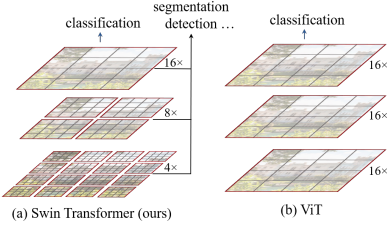

Key differences between Swin Transformer and original Vision Transformer (ViT)
model is that ViT produced feature maps of a **single low resolution** and
because it uses a **global self-attention** ViT has a **quadratic computation
complexity** to input image size.
On the other hand, Swin Transformer builds **hierarchical feature maps** by
merging image patches and it has a **linear computation complexity** to input
image size because it uses local windows for calculating selt-attention.


In this tutorial example, we will discuss the different concepts of the Swin Transformers (the name Swin stands for Shifted window) model and implement it in TensorFlow.

## Overview

As described in the paper [arxiv.org](https://arxiv.org/pdf/2103.14030.pdf) and depicted in the following diagram, SWin Transformer works as follows:

- Each image is split into fixed-size patches of size `4 x 4` then passed to a sequence of stages
- The first stage, Calculate a Patch Embeddings for each patch and also the positional embeddings of the patch then add everything together
- The second, third and forth stages starts by merging patches and then passing them through a Swin Transformer block to calculate feature maps
- At eash of those later stages, the number of channels of the patches is multiplied by 2 and the width and height of the images is divided by 2.

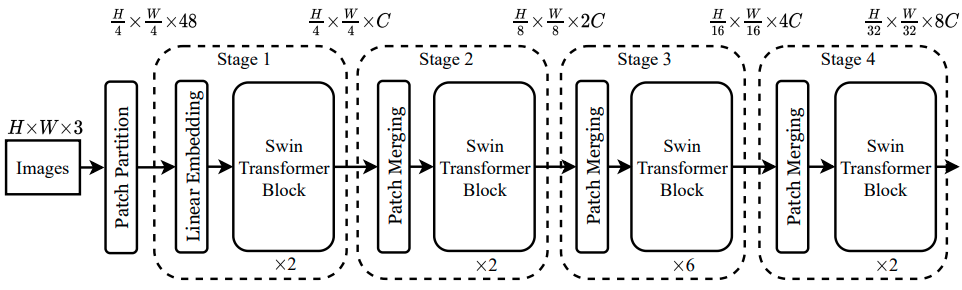

## Implementation

Having built a high level idea of the Swin Transformer Architecture, let's now look at the code-implementation and understand how to implement this architecture in PyTorch. We will be referencing the code from the [Swin-Transformer](https://github.com/microsoft/Swin-Transformer) repository to explain the implementation. For the Tensorflow implementation you can refer to the original implementation of [Swin-Transformer-Tensorflow](https://github.com/VcampSoldiers/Swin-Transformer-Tensorflow).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

### Patch Partition Layer

The first component of the Swin-T architecture is a Path Parition layer which is used to partition an input image into multiple small patches.

In Pytorch, we can simply use the a function to extract patches. We can use it inside a custom Layer to make it easy to use later when building the model

In [2]:
class PatchPartition(nn.Module):
    """Partition an image into patches.

    The first component of the Swin-T architecture is a Patch Partition layer
    which is used to partition an input image into multiple small patches.

    In PyTorch, we can achieve this efficiently using a 2D convolution or 
    the nn.functional.unfold operation.
    """

    def __init__(self, window_size: int = 4, channels: int = 3):
        super().__init__()
        self.window_size = window_size
        self.channels = channels
        
        # Calculate the dimension of each flattened patch (channels * window_size * window_size)
        self.patch_dims = channels * window_size * window_size
        
        # A non-overlapping convolution extracts patches and flattens the spatial/channel features
        self.proj = nn.Conv2d(
            in_channels=channels,
            out_channels=self.patch_dims,
            kernel_size=window_size,
            stride=window_size,
            padding=0
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TensorFlow expects input shape: [batch_size, height, width, channels]
        # PyTorch expects input shape:    [batch_size, channels, height, width]
        # If your images are still in TF format, uncomment the line below to permute them:
        # images = images.permute(0, 3, 1, 2)
        
        # Output shape after projection: [batch_size, patch_dims, H_patches, W_patches]
        patches = self.proj(images)
        
        # Flatten the spatial dimensions into a single sequence dimension: [batch_size, patch_dims, num_patches]
        patches = patches.flatten(2)
        
        # Permute to match TF output shape: [batch_size, num_patches, patch_dims]
        patches = patches.transpose(1, 2)
        
        return patches

The [timm GitHub Repository](https://github.com/huggingface/pytorch-image-models) is the industry standard for Vision Transformers in PyTorch. It features a standalone layer named PatchEmbed that extracts patches using a 2D convolution

We could also use `Conv2d` layer to do the same as a 2-D Convolution uses kernel size (which in our case will be the patch size) and the stride also will be equal to the patch size as we want the windows to not be overlapping.  

Alternatively we can implemnt this using `torch.reshape` like this for instance:

```python
# PyTorch inputs expect Channels-First: [batch, channels, height, width]
batch, channels, height, width = images.shape

patch_num_y = height // window_size
patch_num_x = width // window_size

# 1. Reshape into patches while splitting height and width
new_shape = (batch, channels, patch_num_y, window_size, patch_num_x, window_size)
patches = torch.reshape(images, shape=new_shape)

# 2. Permute dimensions to group patch tokens and flatten them properly
# Target shape before flattening: [batch, patch_num_y, patch_num_x, window_size, window_size, channels]
patches = patches.permute(0, 2, 4, 3, 5, 1)

# 3. Flatten into the final sequence format: [batch, num_patches, patch_dims]
patch_dims = channels * window_size * window_size
patches = torch.reshape(patches, (batch, -1, patch_dims))
```

Let's download a test image and make sure it matches the shape of images in the ImageNet dataset.

In [16]:
!curl -s -o flower.jpeg https://images.unsplash.com/photo-1604085572504-a392ddf0d86a?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8&auto=format&fit=crop&w=224&q=224

In [19]:
import os
print(os.getcwd())
print(os.path.exists("flower.png"))

/home/thomas.li/workshops/ml202_advML_dev
True


(-0.5, 223.5, 223.5, -0.5)

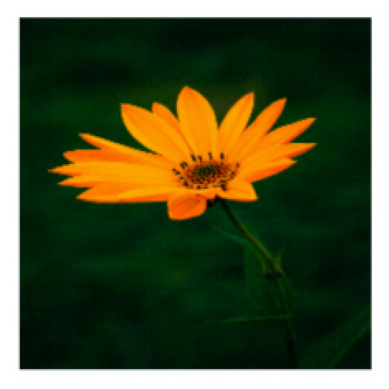

In [46]:
import torchvision.transforms.v2.functional as TF
%matplotlib inline
image = plt.imread("flower.png")
# Convert to a PyTorch tensor and swap to Channels-First format
image = (torch.from_numpy(image).permute(2, 0, 1)*255)
# Resize using Torchvision (expects Channels-First format)
image = TF.resize(image, size=(224, 224))
# Convert back to Channels-Last NumPy array [H, W, C] for Matplotlib display
image = image.permute(1, 2, 0).numpy().astype("uint8")
plt.imshow(image)
plt.axis("off")


The output (-0.5, 223.5, 223.5, -0.5) from plt.axis() after `plt.axis("off")` represents the (xmin, xmax, ymax, ymin) boundaries of the plot. These are adjusted to hide the axes completely. These values are usually slightly outside the image dimensions.

We can apply the images through our `PatchParition` layer

In [51]:
# 1. Convert NumPy array to PyTorch Tensor
image_tensor = torch.from_numpy(image)

# 2. Permute layout to (C, H, W) AND slice out just the first 3 channels (RGB)
# This removes the 4th alpha channel causing the crash!
image_tensor = image_tensor.permute(2, 0, 1)[:3, :, :]

# 3. Convert to float and normalize pixel values between 0.0 and 1.0
image_tensor = image_tensor.float() / 255.0

# 4. Create your 4D batch -> Shape becomes exactly (1, 3, 224, 224)
batch = torch.unsqueeze(image_tensor, dim=0)

# 5. Process through your PatchPartition layer 
patches = PatchPartition()(batch)

# 6. Print the dimensions
print(f"Input shape (B, C, H, W) = {list(batch.shape)}")
print(f"Output shape = {list(patches.shape)}")

Input shape (B, C, H, W) = [1, 3, 224, 224]
Output shape = [1, 3136, 48]


Now we can examine the partitions that we just created

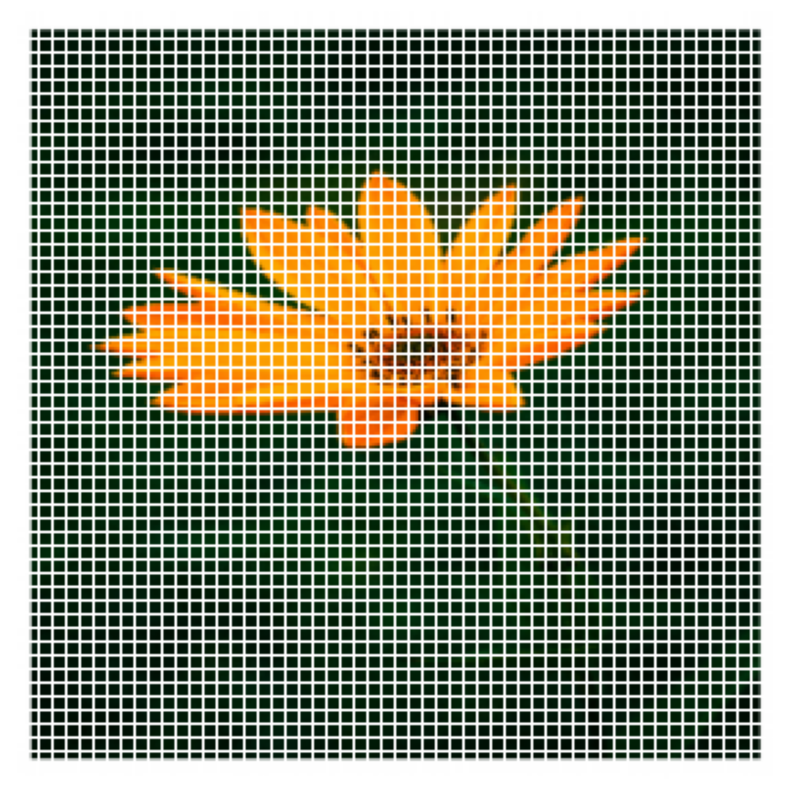

In [66]:
import torchvision

# 1. Use the 'batch' tensor we created earlier (NOT the 'patches' output)
# Extract raw 4x4 pixels directly from the original flower image
unfold = nn.Unfold(kernel_size=4, stride=4)
raw_patches = unfold(batch).transpose(1, 2)  # Shape: (1, 3136, 48)

def visualize_raw_flower_patches(patches: torch.Tensor) -> None:
    num_patches = patches.shape[1]
    
    # Because these are RAW pixels, reshaping to (3, 4, 4) is perfectly accurate!
    all_patches = patches[0].detach().reshape(num_patches, 3, 4, 4)
    
    # Stitch them together into a beautiful grid instantly
    grid_size = int(np.sqrt(num_patches))
    grid = torchvision.utils.make_grid(all_patches, nrow=grid_size, padding=1, pad_value=1)
    
    # Convert from 0.0-1.0 float back to 0-255 uint8 for plotting
    grid_img = grid.permute(1, 2, 0)
    img_to_show = (grid_img * 255).cpu().numpy().astype("uint8")
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img_to_show)
    plt.axis("off")
    plt.show()

# Run this on your RAW patches to see the beautiful cut-up flower pieces!
visualize_raw_flower_patches(raw_patches)

### Linear Embedding layer
The second component in the Swin-T architecture is the Linear Embedding layer which is simply a combination of projection and embedding layers. It is used to calculate the patch embedding and the position embedding then add both as illustrated with the following diagram

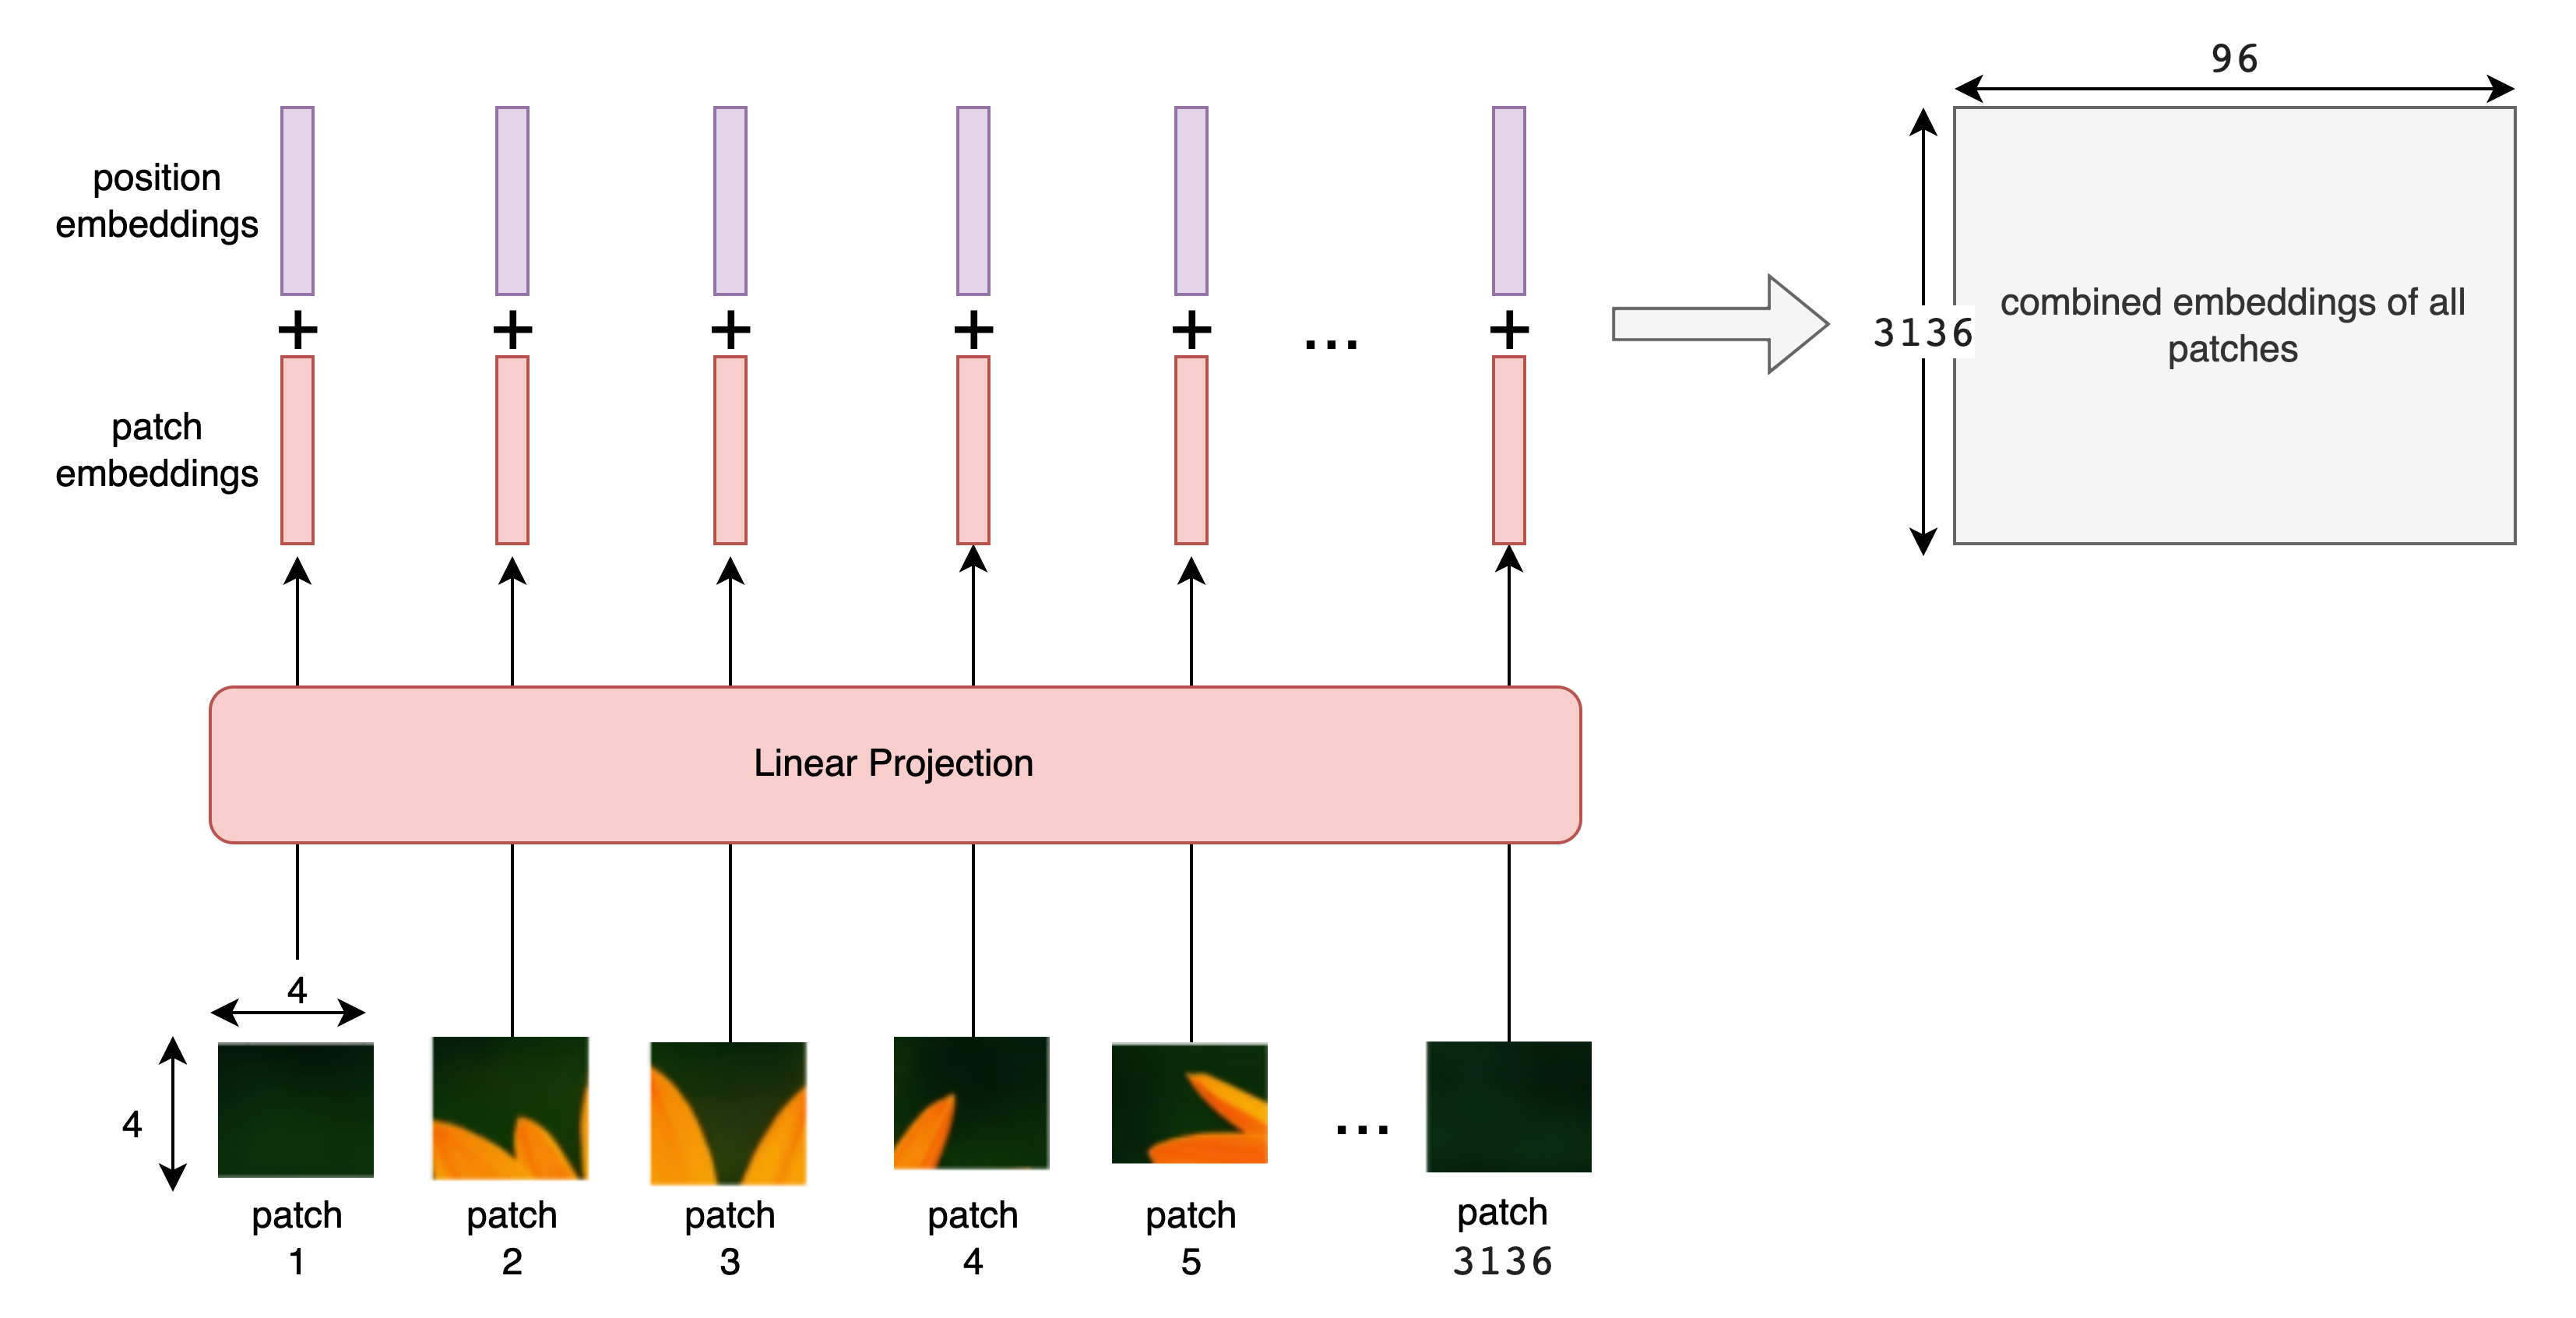

In [68]:
class LinearEmbedding(nn.Module):
    """Calculate patch and position embedding and add them together.

    The second component in the Swin-T architecture is the Linear Embedding
    layer which is simply a combination of projection and embedding layers.
    It is used to calculate the patch embedding and the position embedding then
    add both.
    """

    def __init__(self, num_patches: int, patch_dim: int, projection_dim: int):
        super().__init__()
        self.num_patches = num_patches
        
        # 1. nn.Linear replaces Dense. It requires both input and output dimensions.
        # 'patch_dim' is the size of your flattened patch (e.g., 4*4*3 = 48)
        self.projection = nn.Linear(patch_dim, projection_dim)
        
        # 2. nn.Embedding handles the learned position tracking matrix
        self.position_embedding = nn.Embedding(num_embeddings=num_patches,
                                               embedding_dim=projection_dim)

    def forward(self, patch: torch.Tensor) -> torch.Tensor:
        # patch shape: [Batch, Num_Patches, Patch_Dim]
        
        # 1. Project the raw pixel patches into the embedding dimension space
        patches_embed = self.projection(patch) # Shape: [Batch, Num_Patches, Projection_Dim]
        
        # 2. Create index sequence for positions (0 to num_patches-1)
        # We match the device of the input tensor so it works seamlessly on GPU/CUDA
        positions = torch.arange(0, self.num_patches, dtype=torch.long, device=patch.device)
        
        # 3. Retrieve positional embeddings
        positions_embed = self.position_embedding(positions) # Shape: [Num_Patches, Projection_Dim]
        
        # 4. Add both embeddings together
        # PyTorch automatically broadcasts the positions tensor across the batch dimension
        encoded = patches_embed + positions_embed
        return encoded

We can confirm that:
- the output of this layer is as expected, i.e. `1, 3136, 96`
- number of patches is `num_patch_x * num_patch_y`, i.e. `224 / window_size * 224 / window_size = 3136`
- number of channels is `96`, which equals the `projection_dim` we used in the `LinearEmbedding` layer



In [70]:
# 3136 = num_patches, 48 = patch_dim (input), 96 = projection_dim (output)
embeddings = LinearEmbedding(3136, 48, 96)(patches)
print(embeddings.shape)

torch.Size([1, 3136, 96])


### Patch Merging layer
Patch merging as it may indicate is used to merge smaller patches into larger ones. Let's look at the illustration to understand what this layer is doing, if the input of the layer is an `8 x 8` pixel image with 4 patches of `4 x 4` then the output becomes an `8 x 8` pixels but with one large patch of `8 x 8` plus an additional channel layer as channel layers are doubled.

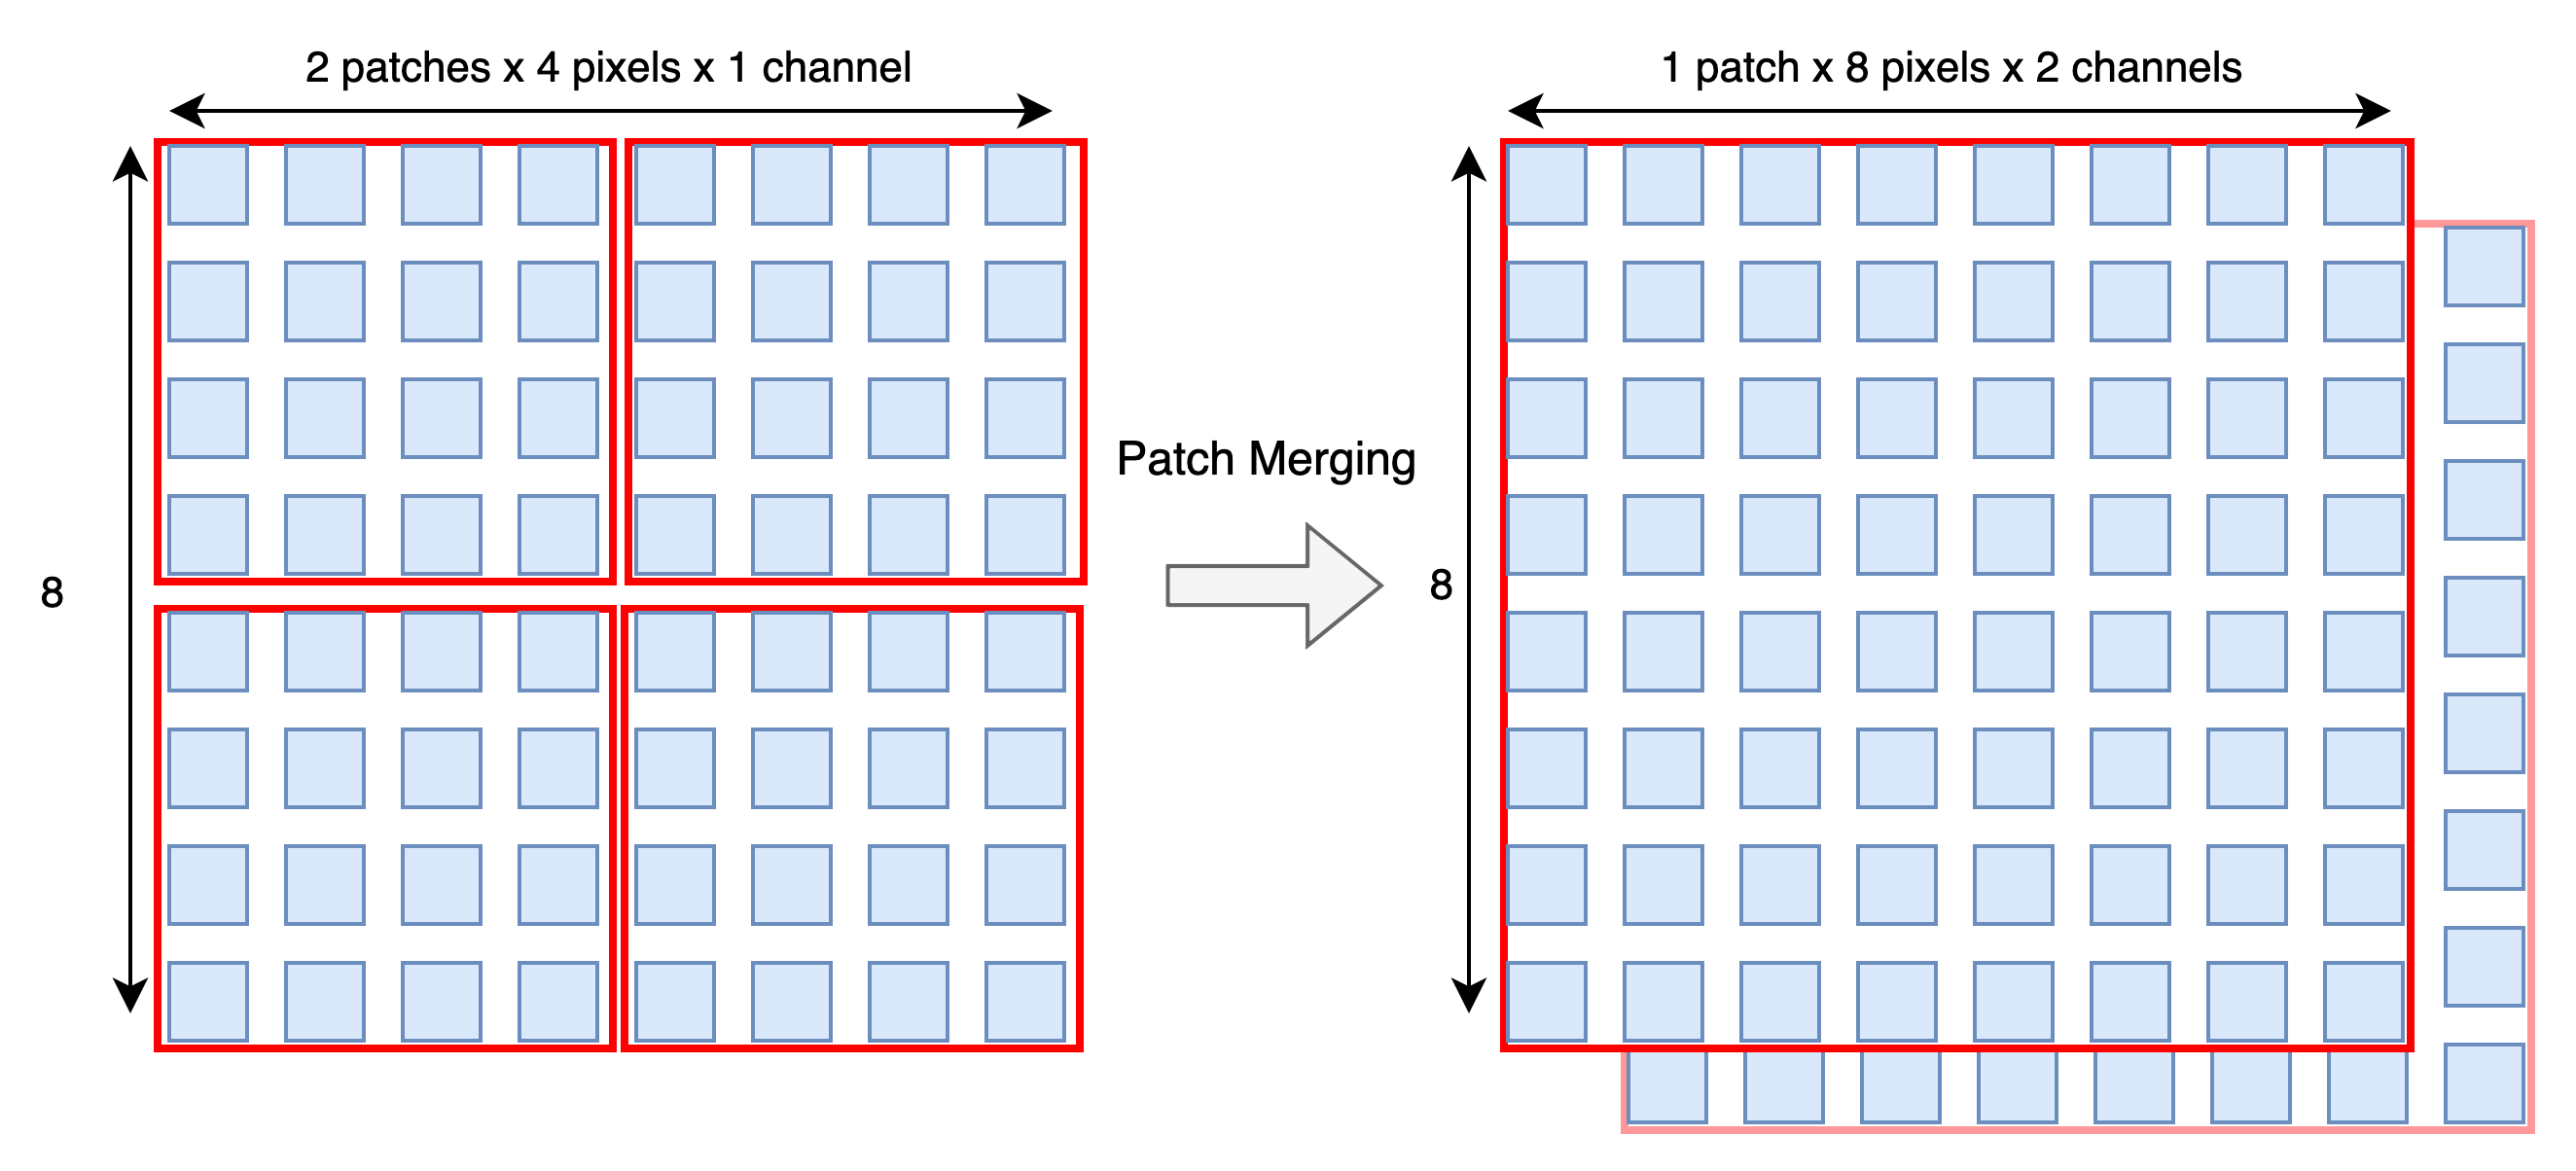

This layer can be simply implemented as a linear layer so that we can easily define the size of the output and double the channels as follows:

In [71]:
class PatchMerging(nn.Module):
    """Merge smaller patches into larger ones (Swin Transformer Stage Transition).

    This layer takes a flattened sequence of patches, reshapes them back to a 
    2D grid, selects pixel elements at even/odd indices (patch downsampling), 
    concatenates the groups along the channels, and applies a linear projection 
    to double the channel depth while cutting spatial resolution in half.
    """

    def __init__(self, input_resolution: tuple[int, int], channels: int):
        super().__init__()
        self.input_resolution = input_resolution
        self.channels = channels
        
        # In PyTorch, nn.Linear needs (input_dim, output_dim).
        # Concatenating x0, x1, x2, x3 creates 4 * channels features.
        # The output target is 2 * channels.
        self.linear_trans = nn.Linear(4 * channels, 2 * channels, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Expected input x shape: [Batch, Num_Patches, Channels] 
        # (e.g., [B, 3136, 96] for a 56x56 patch grid)
        
        height, width = self.input_resolution
        batch_size, seq_len, c = x.shape
        
        # Safety check to ensure the resolution dimensions match your incoming sequence
        assert seq_len == height * width, "Input feature sequence length does not match resolution dimensions"
        
        # 1. Reshape the flat sequence back into a 2D spatial grid layout: [B, H, W, C]
        x = x.view(batch_size, height, width, c)
        
        # 2. Slice into 4 sub-grids using strided downsampling (even/odd combinations)
        x0 = x[:, 0::2, 0::2, :] # Top-left elements
        x1 = x[:, 1::2, 0::2, :] # Bottom-left elements
        x2 = x[:, 0::2, 1::2, :] # Top-right elements
        x3 = x[:, 1::2, 1::2, :] # Bottom-right elements
        
        # 3. Concatenate the sub-grids along the channel axis (dim=-1)
        # Spatial shape drops to (H//2, W//2), Channel shape scales to 4*C
        x = torch.cat((x0, x1, x2, x3), dim=-1)
        
        # 4. Flatten the downsampled spatial grid back into a sequence vector layout
        x = x.view(batch_size, (height // 2) * (width // 2), 4 * c)
        
        # 5. Project features from 4*C down to 2*C using our linear layer matrix
        return self.linear_trans(x)

In [74]:
num_patch_x = 224 // 4
num_patch_y = 224 // 4

# 1. First project patches from 48 features to 96 embedded channels
embeddings = LinearEmbedding(3136, 48, 96)(patches) # Output shape: (1, 3136, 96)

# 2. Now pass the 96-channel embeddings into PatchMerging
channels = 96
out_patches = PatchMerging((num_patch_x, num_patch_y), channels)(embeddings)

print(f"Input shape (B, H * W, C) = {embeddings.shape}")
print(f"Output shape (B, H/2*W/2, 2C) = {out_patches.shape}")

Input shape (B, H * W, C) = torch.Size([1, 3136, 96])
Output shape (B, H/2*W/2, 2C) = torch.Size([1, 784, 192])


### Swin Transfomer block
The Swin Transformer block combines two Transofmer Encoder blocks but uses a window based self-attentions as illustrated in the following diagram. In this section, we will examine each component of this bloc and implement it in PyTorch

> Note: W-MSA stands for Window Multi-head Self-Attention and SW-MSA stands for Shifted Window Multi-head Self-Attention.

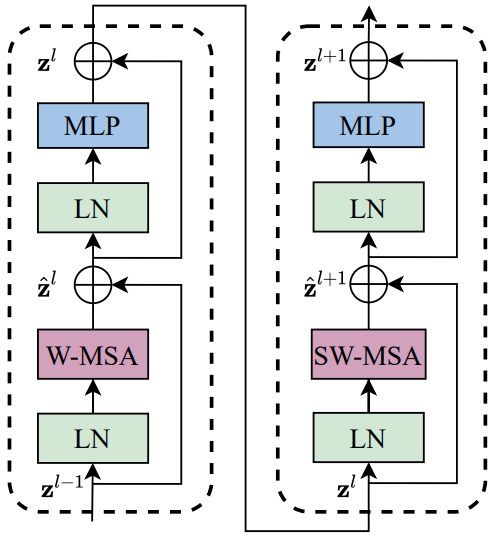

#### Multilayer Perceptron
A Multilayer Perceptron (MLP) consists basically two dense layers and a GELU activation layer. It is used in the classical Transformer architecture and it is also used in the Swin Transformer blocks. We can simply implement it as custom layer as follows:

In [76]:
class MLP(nn.Module):
    """Multilayer Perceptron (MLP) with GELU activation.

    A Multilayer Perceptron (MLP) consists basically two dense layers and a
    GELU activation layer.
    It is used in the classical Transformer architecture and it is also used in
    the Swin Transformer blocks.
    We can simply implement it as custom layer as follows:
    """

    def __init__(
        self,
        in_features: int,
        hidden_features: int,
        out_features: int,
        dropout_rate: float = 0.1,
    ):
        super().__init__()
        self.dense1 = nn.Linear(in_features, hidden_features)
        self.gelu = nn.GELU()
        self.dense2 = nn.Linear(hidden_features, out_features)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.dense1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        x = self.dense2(x)
        y = self.dropout(x)
        return y

In [78]:
mlp = MLP(in_features=768, hidden_features=768 * 2, out_features=768)
shape_in = (1, 197, 768)
y = mlp(torch.zeros(shape_in))
# For MLP, the output shape should be the same as the input shape
assert tuple(y.shape) == shape_in

### Summary of Omitted Attention Components

* **Local Window Self-Attention (W-MSA & SW-MSA)**: The local window constraint and shifted window tracking mechanisms which restrict attention calculations to specific local patch clusters.
* **Relative Position Bias Tables**: The learnable relative coordinate tables used to add spatial location metrics within attention matrices.
* **Cyclic Shifting Helpers**: `window_partition` and `window_reverse` logic, alongside tensor `torch.roll` operations that handle edge-case patch transformations.
* **DropPath (Stochastic Depth)**: The specialized regularization layer used during training to randomly drop layer pathways.


## Putting it together
After defining all the major components of the Swin-T architecture, we can put them together to build the model. This is fairly straightforward now as we just need to plug a window partition to an blocks of Swin Transformers separated by a merging layer. For classification, we add a pooling then a dense layer to the form the head of the model.



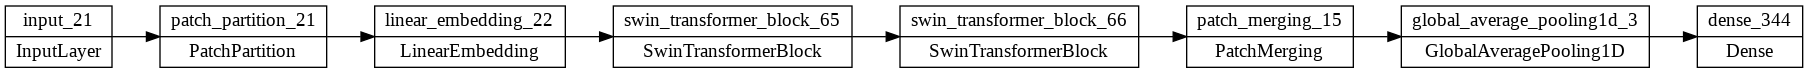

In [83]:
def create_swintransformer(
    num_classes: int,
    *,
    input_shape: tuple[int, int, int] = (3, 224, 224), # PyTorch uses (Channels, H, W)
    window_size: int = 4,
    embed_dim: int = 96,
    num_heads: int = 8,
) -> nn.Module: # FIX: Changed 'Model' to 'nn.Module'
    """Create a Swin Transformer s tructural pipeline base.

    This compiles the initialized patch partitioning, sequence projections,
    and downsampling layers in PyTorch sequence format.
    """
    channels, height, width = input_shape
    num_patch_x = height // window_size
    num_patch_y = width // window_size
    num_patches = num_patch_x * num_patch_y

    # Pipeline Assembly using nn.Sequential container
    model = nn.Sequential(
        # 1. Image to Patches (B, 3, 224, 224) -> (B, 3136, 48)
        PatchPartition(window_size=window_size, channels=channels),
        
        # 2. Add Location Tracking Vector -> (B, 3136, 96)
        LinearEmbedding(num_patches=num_patches, patch_dim=channels*window_size*window_size, projection_dim=embed_dim),
        
        # 3. Strided Merging Layer Downsampling -> (B, 784, 192)
        PatchMerging(input_resolution=(num_patch_x, num_patch_y), channels=embed_dim)
    )
    
    return model

# Test the compilation setup
model = create_swintransformer(num_classes=2)
print(model)

Sequential(
  (0): PatchPartition(
    (proj): Conv2d(3, 48, kernel_size=(4, 4), stride=(4, 4))
  )
  (1): LinearEmbedding(
    (projection): Linear(in_features=48, out_features=96, bias=True)
    (position_embedding): Embedding(3136, 96)
  )
  (2): PatchMerging(
    (linear_trans): Linear(in_features=384, out_features=192, bias=False)
  )
)


> Note: In our case we are using only one stage of Swin Transformer blocks. In the original paper, there are 4 of those stages.

In [84]:
model = create_swintransformer(2)

In [88]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [89]:
from torchinfo import summary

# Pass your model object and define the input batch geometry shape
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 784, 192]             --
├─PatchPartition: 1-1                    [1, 3136, 48]             --
│    └─Conv2d: 2-1                       [1, 48, 56, 56]           2,352
├─LinearEmbedding: 1-2                   [1, 3136, 96]             --
│    └─Linear: 2-2                       [1, 3136, 96]             4,704
│    └─Embedding: 2-3                    [3136, 96]                301,056
├─PatchMerging: 1-3                      [1, 784, 192]             --
│    └─Linear: 2-4                       [1, 784, 192]             73,728
Total params: 381,840
Trainable params: 381,840
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 951.57
Input size (MB): 0.60
Forward/backward pass size (MB): 7.23
Params size (MB): 1.53
Estimated Total Size (MB): 9.35

## Reference

- [Swin Transformer: Hierarchical Vision Transformer using Shifted Windows](https://arxiv.org/abs/2103.14030)
- [Swin Transformer Explained with a TensorFlow implementation](https://colab.research.google.com/github/dzlab/notebooks/blob/master/_notebooks/2022-02-27-Swin_Transfomer.ipynb)

This PyTorch-based .ipynb example compares a traditional Convolutional Neural Network (ResNet-18) against a Swin Transformer (Swin-T) by fine-tuning both on a custom image classification task (e.g., a subset of CIFAR-10). It utilizes Hugging Face's transformers and torchvision for model loading and fine-tuning. [ViT Classification](https://github.com/sergio-sanz-rodriguez/Vision-Transformers-Image-Classification)

## 1. Installation & Imports

In [1]:
# !pip install -q transformers datasets torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from transformers import AutoImageProcessor, SwinForImageClassification
import torchvision.models as models
import matplotlib.pyplot as plt


## 2. Data Preparation & Augmentation
Transformers generally expect different normalization and sizes compared to standard CNNs
[Swin-Pose Paper](https://ar5iv.labs.arxiv.org/html/2201.07384)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

transform_cnn = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_swin = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Load and split datasets
full_train_cnn = datasets.CIFAR10('./data', train=True, download=True, transform=transform_cnn)
full_train_swin = datasets.CIFAR10('./data', train=True, download=True, transform=transform_swin)

train_len = int(len(full_train_cnn) * 0.8)
val_len = len(full_train_cnn) - train_len

torch.manual_seed(42) # Ensure identical splits
train_ds_cnn, val_ds_cnn = random_split(full_train_cnn, [train_len, val_len])
train_ds_swin, val_ds_swin = random_split(full_train_swin, [train_len, val_len])

train_loader_cnn = DataLoader(train_ds_cnn, batch_size=32, shuffle=True)
val_loader_cnn = DataLoader(val_ds_cnn, batch_size=32, shuffle=False)

train_loader_swin = DataLoader(train_ds_swin, batch_size=32, shuffle=True)
val_loader_swin = DataLoader(val_ds_swin, batch_size=32, shuffle=False)


## 3. Setup Model 1: Fine-Tuning a CNN (ResNet-18)
We will load a pretrained ResNet-18 and replace the final fully-connected layer to match our target number of classes.

In [3]:
cnn_model = models.resnet18(pretrained=True)

# Freeze early layers
for param in cnn_model.parameters():
    param.requires_grad = False

# Replace the classification head
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, 10) 
cnn_model = cnn_model.to(device)


/nesi/project/nesi99999/thomas.li/pytorch_ml/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/nesi/project/nesi99999/thomas.li/pytorch_ml/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 4. Setup Model 2: Fine-Tuning a Swin Transformer
We will use Hugging Face's SwinForImageClassification. Swin breaks images into patches and uses shifted-window self-attention, giving it global spatial understanding

You can safely ignore the "size mismatch" warning; it just means the model replaced its original 1,000-class layer with a new 10-class layer for our dataset while keeping the pretrained layers intact.

In [4]:
swin_model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=10,
    ignore_mismatched_sizes=True
)

# Freeze some of the base transformer layers to save memory/prevent overfitting
for name, param in swin_model.named_parameters():
    if "classifier" not in name:  # Unfreeze only the classification head for fine-tuning
        param.requires_grad = False

swin_model = swin_model.to(device)


You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


## 5. Training Loop
Here is a simplified standard PyTorch training function that can be used identically for both models.

In [5]:
def train_and_evaluate(model, train_loader, val_loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        correct_train, total_train = 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(logits, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        train_accuracy = (correct_train / total_train) * 100
        history['train_acc'].append(train_accuracy)
        
        # Validation Phase
        model.eval()
        correct_val, total_val = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                
                _, predicted = torch.max(logits, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
        val_accuracy = (correct_val / total_val) * 100
        history['val_acc'].append(val_accuracy)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}%")
        
    return history


## 6. Execution

In [ ]:
print("--- Training CNN (ResNet-18) ---")
cnn_history = train_and_evaluate(cnn_model, train_loader_cnn, val_loader_cnn, epochs=3)

print("\n--- Training Swin Transformer ---")
swin_history = train_and_evaluate(swin_model, train_loader_swin, val_loader_swin, epochs=3)


--- Training CNN (ResNet-18) ---


## 7. Plotting the Comparison

In [ ]:
epochs_range = range(1, 4)

plt.figure(figsize=(12, 5))

# Plot CNN History
plt.subplot(1, 2, 1)
plt.plot(epochs_range, cnn_history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(epochs_range, cnn_history['val_acc'], label='Val Accuracy', marker='s')
plt.title('CNN (ResNet-18) Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

# Plot Swin History
plt.subplot(1, 2, 2)
plt.plot(epochs_range, swin_history['train_acc'], label='Train Accuracy', marker='o', color='purple')
plt.plot(epochs_range, swin_history['val_acc'], label='Val Accuracy', marker='s', color='orange')
plt.title('Swin Transformer Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
